In [1]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from '/content/helper.py'>

### Try with Transfer Learning with EfficientNetB1

##### Dataset loading and preprocessing

In [4]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
import os
import shutil
import kagglehub

# Download dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# Move dataset to parent directory
shutil.move(os.path.join(path, 'COVID-19_Radiography_Dataset'), "..")
print("Covid-19 Radiography Dataset downloaded and moved to parent directory.")

100%|██████████| 778M/778M [00:35<00:00, 23.1MB/s]

Extracting files...


Covid-19 Radiography Dataset downloaded and moved to parent directory.


In [20]:
# Read in the images
train_ds, val_ds, class_names = helper.read_only_xray_images(input_shape=(256,256))

Created empty directory: /tmp_560327512
Made directory: /tmp_560327512/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_560327512/COVID/masks
Made directory: /tmp_560327512/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_560327512/Normal/masks
Made directory: /tmp_560327512/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_560327512/Lung_Opacity/masks
Made directory: /tmp_560327512/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_560327512/Viral Pneumonia/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 256, 256, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 256, 256, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_560327512/COV

In [21]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 256, 256, 3) (32,)
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 3
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 3
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0


In [22]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


#### Try with EfficientNetB1 (pretrained)

In [9]:
# This model name for saving and loading
model_name = 'efficientnetb1_' + str(len(class_names)) + '-classes.keras'

In [10]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
#from tensorflow.keras.applications.efficientnet import preprocess_input

#train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
#val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [43]:
# Imports for using a pre-trained model
from tensorflow.keras.applications import EfficientNetB1

# EfficientNetB1 model
base_model = EfficientNetB1(include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the base model
#base_model.trainable = False
for layer in base_model.layers[:-5]:
    layer.trainalbe = False

# Let's apply some finetuning by retraining the last 5 layers
for layer in base_model.layers[-5:]:
    layer.trainalbe = True

# Model creation using the Functional API
inputs = Input(shape=(256, 256, 3))

# Preprocessing
x = preprocess_input(inputs)

# Build the model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

effnet = Model(inputs=inputs, outputs=outputs)

In [30]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [44]:
# Compile with first idea of appropriate parameters
effnet.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
effnet.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = helper.model_summary_to_df(effnet)
display(df_summary)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)          │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb1 (Functional)          │ (None, 8, 8, 1280)          │       6,575,239 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_10          │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,018,699 (30.59 MB)

 Trainable params: 7,956,644 (30.35 MB)

 Non-trainable params: 62,055 (242.41 KB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_21 (InputLayer),"(None, 256, 256, 3)",0
1,efficientnetb1 (Functional),"(None, 8, 8, 1280)","6,575,239"
2,global_average_pooling2d_10,"(None, 1280)",0
3,(GlobalAveragePooling2D),,
4,dense_30 (Dense),"(None, 1024)","1,311,744"
5,dropout_20 (Dropout),"(None, 1024)",0
6,dense_31 (Dense),"(None, 128)","131,200"
7,dropout_21 (Dropout),"(None, 128)",0
8,dense_32 (Dense),"(None, 4)",516


In [45]:
# Train it with the entire dataset (takes very long!)
history_model = effnet.fit(train_ds,
                          epochs=20,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 234s 244ms/step - accuracy: 0.8155 - loss: 0.4454 - val_accuracy: 0.9107 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.9193 - loss: 0.1787 - val_accuracy: 0.9086 - val_loss: 0.3272 - learning_rate: 0.0010
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.9155 - loss: 0.1874 - val_accuracy: 0.9369 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.9269 - loss: 0.1563 - val_accuracy: 0.9272 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 5/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.9331 - loss: 0.1335 - val_accuracy: 0.8949 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 6/20
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9424 - loss: 0.1489
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.9

In [46]:
# Save the model for potential later use
effnet.save(model_name)

##### Evalution

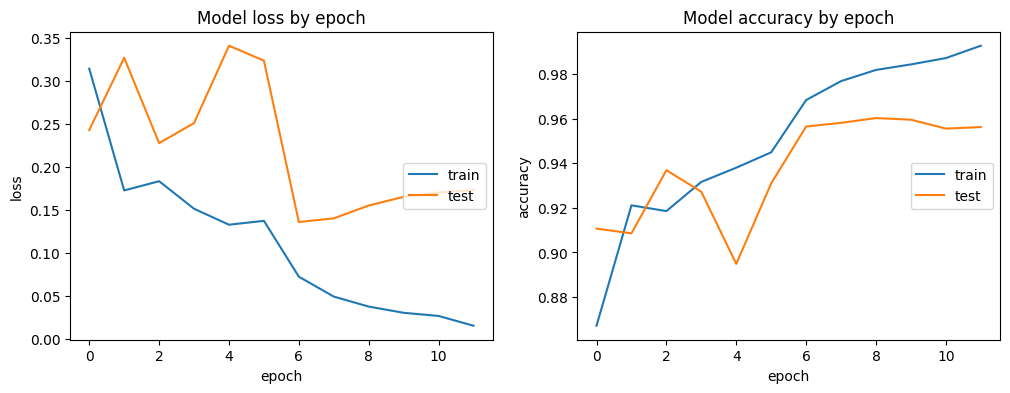

In [47]:
helper.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [48]:
from tensorflow import keras
effnet = keras.models.load_model(model_name)

In [49]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = helper.get_predictions_and_labels(effnet, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.987448,0.992987,0.997443,0.990210,0.995213,0.990007,713.000000
Lung_Opacity,0.930591,0.932189,0.973598,0.931389,0.952669,0.903819,1165.000000
Normal,0.958944,0.953353,0.961379,0.956140,0.957358,0.915798,2058.000000
Viral Pneumonia,0.963696,0.983165,0.997205,0.973333,0.990160,0.979041,297.000000
avg_pre,0.956275,0.956275,0.956275,0.956275,0.956275,0.956275,0.956275
avg_rec,0.956296,0.956296,0.956296,0.956296,0.956296,0.956296,0.956296
avg_spe,0.973330,0.973330,0.973330,0.973330,0.973330,0.973330,0.973330
avg_f1,0.956273,0.956273,0.956273,0.956273,0.956273,0.956273,0.956273
avg_geo,0.964745,0.964745,0.964745,0.964745,0.964745,0.964745,0.964745
avg_iba,0.929438,0.929438,0.929438,0.929438,0.929438,0.929438,0.929438


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,708,0,4,1
Lung_Opacity,3,1086,76,0
Normal,5,81,1962,10
Viral Pneumonia,1,0,4,292


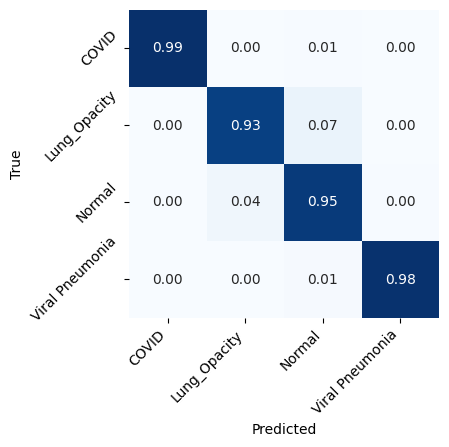

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              708             0       4                1
 Lung_Opacity         3          1086      76                0
 Normal               5            81    1962               10
 Viral Pneumonia      1             0       4              292,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.987448     0.992987     0.997443     0.990210   
 Lung_Opacity        0.930591     0.932189     0.973598     0.931389   
 Normal              0.958944     0.953353     0.961379     0.956140   
 Viral Pneumonia     0.963696     0.983165     0.997205     0.973333   
 avg_pre             0.956275     0.956275     0.956275     0.956275   
 avg_rec             0.956296     0.956296     0.956296     0.956296   
 avg_spe             0.973330     0.973330     0.973330     0.973330   
 avg_f1              0.956273     0.956273     0.956273     0.956273   

In [50]:
helper.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest